# Toy Example of S-phase Copy Number Replication Normalization

May 24, 2024

## Goal:
Create a procedure to make clear the copy number correction process

## Inputs:
- Raw gene expression reads
- Replication timing profile (deconvolved time, more granular than the experiment)
- H matrix with information on how much of each cell has progressed through the cell cycle.



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


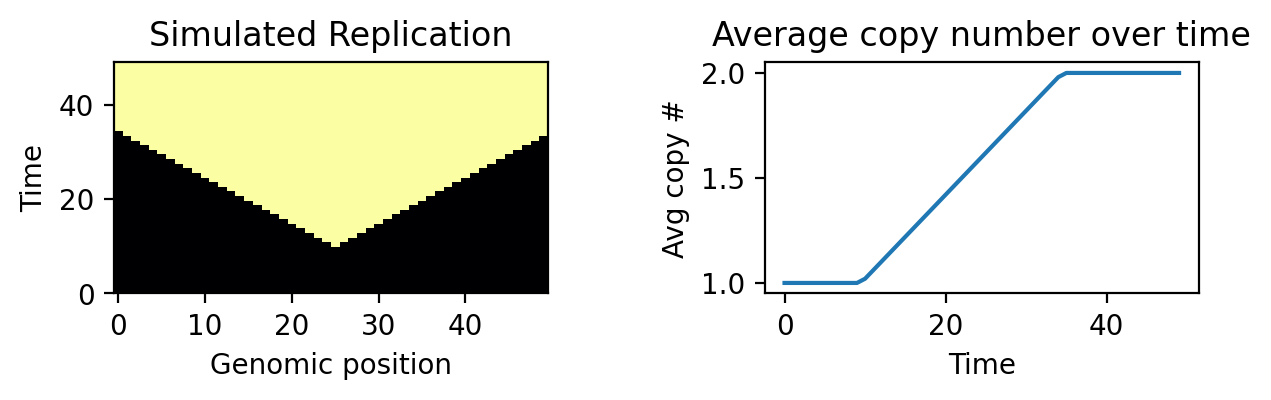

In [435]:
from src.ToyReplication import ToyReplication

# Let's create a replication profile with the dimensions of H
from src.delta_config import load_yl_delta_config
from src.helpers import calcH

length_timecourse = 50
step_min = 10 # Progress time by 10 minutes

# Deconvolution timepoints for fine grained replication timing
deconv_tps = np.arange(0, length_timecourse, 1)

# Experimental timepoints for the observed data later on
tps = np.arange(0, length_timecourse, step_min)

n = 50 # 50 genomic positions
origins = { 10:[25] } # One origin that fires at 25 bp at 10 min

# Replication profile 
toy_repl_example = ToyReplication(n=n, timepoints=deconv_tps, origins=origins)
toy_repl_example.replicate()
toy_repl_example.plot_replication()


In [436]:
observed_reads = np.ones((len(tps), n))

In [437]:
toy_repl_example.set_reads(observed_reads, tps)
toy_repl_example.copy_number_correction()

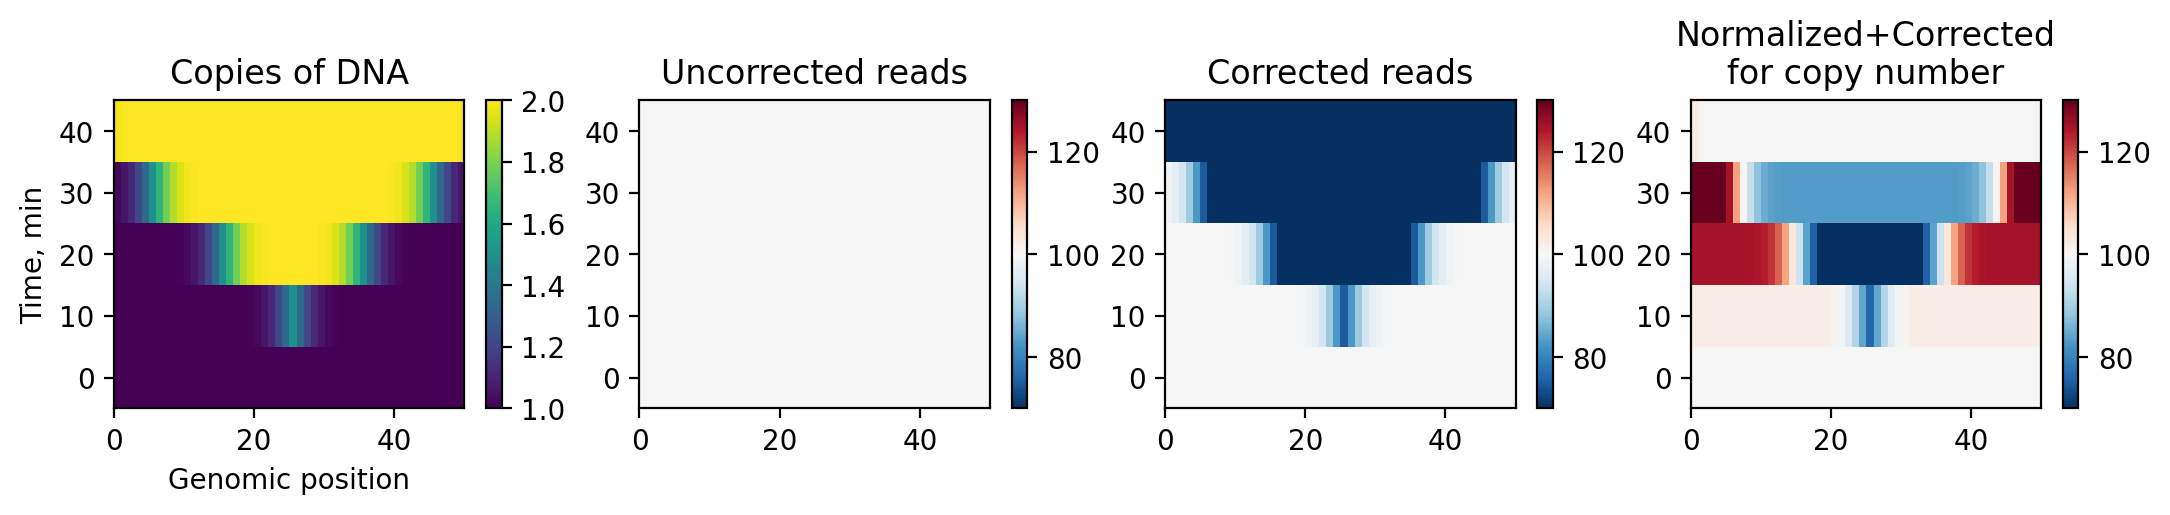

In [490]:
toy_repl_example.plot_correction()

Text(0.5, 1.0, 'Normalized+Corrected\nfor copy number')

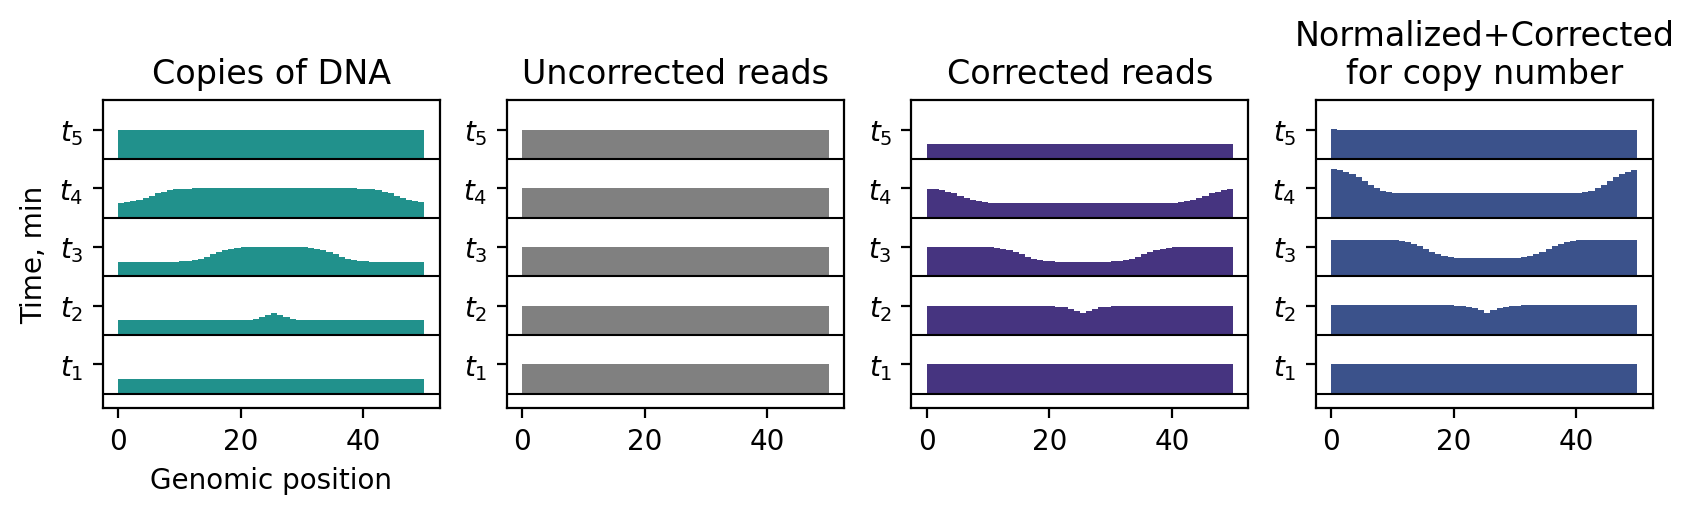

In [489]:
from src.ToyCopyNumberCorrect import plot_reads_bar
plt.figure(figsize=(10, 2))
plt.subplot(1, 4, 1)
plot_reads_bar(toy_repl_example.copy_num_2_props+1., scale=2,
              color=plt.get_cmap('viridis')(0.5))
plt.title("Copies of DNA")
plt.ylabel("Time, min")
plt.xlabel("Genomic position")
    
plt.subplot(1, 4, 2)
plot_reads_bar(toy_repl_example.reads, scale=1)
plt.title("Uncorrected reads")

plt.subplot(1, 4, 3)
plot_reads_bar(toy_repl_example.corrected_copy_num_reads, scale=100,
                color=plt.get_cmap('viridis')(0.15))
plt.title("Corrected reads")

plt.subplot(1, 4, 4)
plot_reads_bar(toy_repl_example.normalized_corrected_reads, scale=100,
                color=plt.get_cmap('viridis')(0.25))
plt.title("Normalized+Corrected\nfor copy number")

Text(0.5, 1.0, 'Example cell cycle progression + replication time')

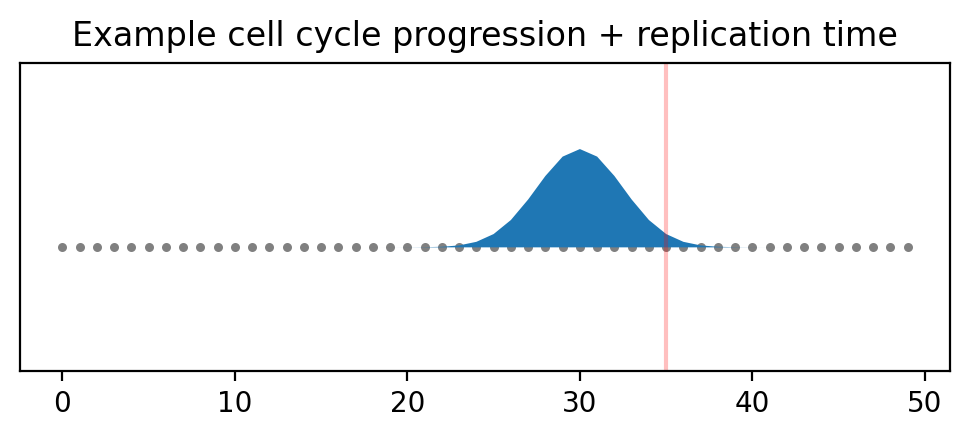

In [488]:
from scipy.stats.distributions import norm

# shape: deconvolution timepoints, number of genomic positions
m, n = toy_repl_example.replication_matrix.shape

t = 30

"""Creates a plot of the cell population progressing through the cell cycle as a 
normal distribution"""
xs = np.arange(m)
ys = norm.pdf(xs, loc=t, scale=toy_repl_example.std)

plt.figure(figsize=(6, 2))
plt.ylim(-0.2, 0.3)
plt.scatter(xs, np.repeat(0, m), c='gray', s=5)
plt.fill_between(xs, ys, 0)
plt.axvline(toy_repl_example.replication_times[0], c='red', alpha=0.25)
plt.yticks([])
plt.title("Example cell cycle progression + replication time")